In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score

# 1. 데이터 로드 (경로는 사용자 환경에 맞춰 수정 가능)
df = pd.read_csv('/Users/user/Desktop/bitamin/26_winter_proj/data/KFG/KFG_final_2.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. 결측치 처리 및 기본 전처리
df = df.fillna(method='ffill').fillna(method='bfill')

# 3. 고도화된 피처 엔지니어링 (Step 3)
def build_features(df):
    df = df.copy()
    # 감성 지표 반전 및 에너지 (직관적 해석을 위해)
    df['neg_z_inv'] = -df['neg_z']
    df['sent_std_inv'] = -df['sent_std']
    df['sent_energy'] = df['sent_strength_w'] * df['sent_norm_w']

    # 변화율 및 이동평균 (모멘텀 파악)
    df['sent_norm_diff'] = df['sent_norm_w'].diff()
    df['neg_z_diff'] = df['neg_z'].diff()
    df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
    df['neg_z_ma5'] = df['neg_z'].rolling(5).mean()

    # 기존 서브 인덱스 Lag (과거 데이터로 미래 예측)
    sub_cols = [f'sub_index{i}' for i in range(1, 8)]
    for col in sub_cols:
        df[f'{col}_lag1'] = df[col].shift(1)

    # 타겟 설정
    df['target_reg'] = df['log_return_t+1']
    df['target_cls'] = (df['log_return_t+1'] > 0).astype(int)

    # 샘플 가중치 (데이터 신뢰도 반영)
    df['sample_weight'] = np.log1p(df['effective_n'])

    return df.dropna().reset_index(drop=True)

df_eng = build_features(df)

/opt/anaconda3/envs/bkh/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_16978/3083258785.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


In [4]:
## Step 5: 경제적 의미를 반영한 K-FGI 생성 (수정본)

def create_logical_kfgi(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end

    # 1. 지수 구성 피처 정의
    core_feats = [f'sub_index{i}' for i in range(1, 8)] + \
                 ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv']

    # 2. 경제적 방향성 사전 정의 (1: 높을수록 탐욕, -1: 높을수록 공포)
    # sub_index5가 이미 역전된 VKOSPI라면, 지수 내에서는 + 방향이어야 '탐욕' 시 높아짐
    # 만약 원본 VKOSPI라면 -1을 곱해야 함. 여기서는 사용자님의 sub_index 정의를 따름.
    directions = {
        'sub_index1': 1, 'sub_index2': 1, 'sub_index3': 1, 'sub_index4': 1,
        'sub_index5': 1, 'sub_index6': 1, 'sub_index7': 1,
        'sent_norm_w': 1, 'sent_energy': 1, 'sent_std_inv': 1, 'neg_z_inv': 1
    }
    dir_vector = np.array([directions[col] for col in core_feats])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[core_feats])

    # 3. Ridge로 '중요도' 파악
    ridge = RidgeCV(alphas=np.logspace(-2, 2, 10))
    ridge.fit(X_scaled[train_mask], df.loc[train_mask, 'target_reg'])

    # 4. 가중치 재설계: (Ridge 절대값 계수) * (사전 정의 방향)
    # 이렇게 하면 수익률과 상관성이 높은 변수가 큰 비중을 갖되, 부호는 직관을 따름
    logical_weights = np.abs(ridge.coef_) * dir_vector
    normalized_weights = logical_weights / np.sum(np.abs(logical_weights))

    # 5. 지수 산출
    raw_fgi = X_scaled @ normalized_weights

    # 6. 0~100 스케일링
    p1, p99 = np.percentile(raw_fgi[train_mask], [1, 99])
    df['K_FGI'] = 100 * (np.clip(raw_fgi, p1, p99) - p1) / (p99 - p1)

    return df, normalized_weights, core_feats

df_fgi, final_weights, core_feats = create_logical_kfgi(df_eng)

# 결과 확인
weight_df = pd.DataFrame({'Feature': core_feats, 'Weight': final_weights}).sort_values(by='Weight', ascending=False)
print("=== Adjusted K-FGI Weights (Economic Logic Applied) ===")
print(weight_df)

=== Adjusted K-FGI Weights (Economic Logic Applied) ===
         Feature    Weight
4     sub_index5  0.241145
6     sub_index7  0.198212
3     sub_index4  0.146091
9   sent_std_inv  0.132972
5     sub_index6  0.118793
8    sent_energy  0.052284
10     neg_z_inv  0.039177
7    sent_norm_w  0.036820
1     sub_index2  0.025231
0     sub_index1  0.008907
2     sub_index3  0.000369


In [5]:
# 7~8. 실험 설계 및 모델링 (Step 7, 8)
train_end = '2024-12-31'
train_df = df_fgi[df_fgi['date'] <= train_end]
test_df = df_fgi[df_fgi['date'] > train_end]

features = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
           ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
            'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5', 'neg_z_ma5', 'K_FGI']

# 하이퍼파라미터 설정 (성능 최적화)
params_reg = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': 42
}

params_cls = params_reg.copy()
params_cls.update({'objective': 'binary', 'metric': 'binary_logloss'})

# 모델 학습
dtrain_reg = lgb.Dataset(train_df[features], label=train_df['target_reg'], weight=train_df['sample_weight'])
dtrain_cls = lgb.Dataset(train_df[features], label=train_df['target_cls'], weight=train_df['sample_weight'])

model_reg = lgb.train(params_reg, dtrain_reg, num_boost_round=500)
model_cls = lgb.train(params_cls, dtrain_cls, num_boost_round=500)

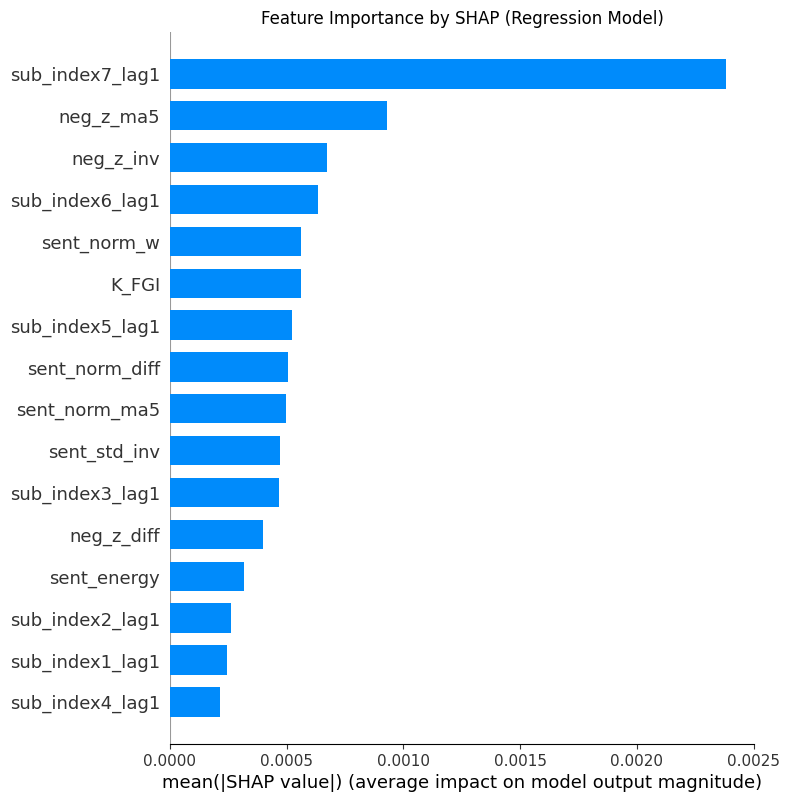

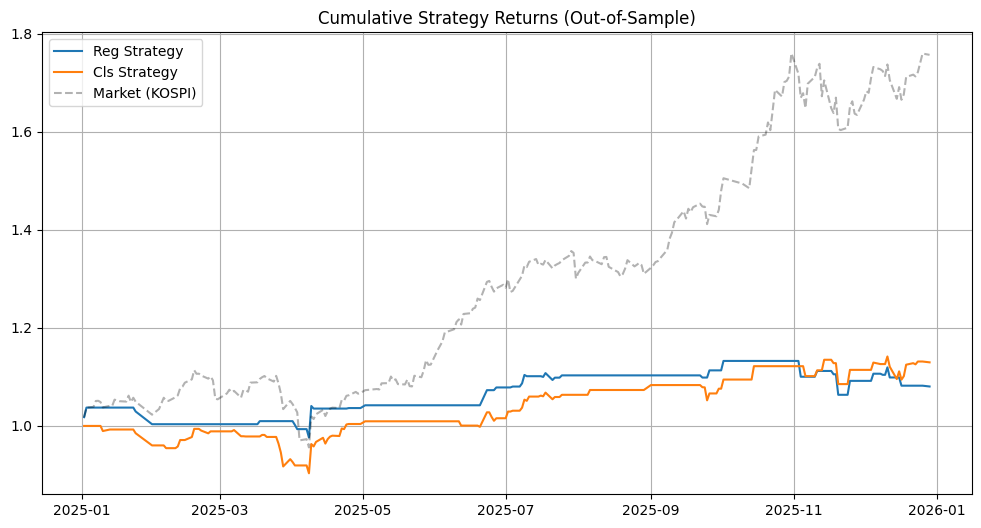


===== 최종 모델 성과 요약 =====
 Strategy Annual Return  Sharpe
strat_reg         8.09%   0.720
strat_cls        12.75%   0.934
   market        58.91%   2.729


In [6]:
# 10. SHAP 분석 및 시각화 (Step 10)
explainer = shap.TreeExplainer(model_reg)
shap_values = explainer.shap_values(test_df[features])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_df[features], plot_type="bar", show=False)
plt.title("Feature Importance by SHAP (Regression Model)")
plt.show()

# 11. 전략 성과 평가 및 시각화 (Step 11)
def evaluate_strategy(df_test, model_reg, model_cls, features):
    # 예측치 생성
    df_test = df_test.copy()
    df_test['pred_reg'] = model_reg.predict(df_test[features])
    df_test['pred_cls'] = model_cls.predict(df_test[features])

    # 전략 수익률 계산 (Regression: pred > 0, Classification: pred > 0.5 일 때 매수)
    df_test['strat_reg'] = (df_test['pred_reg'] > 0).astype(int) * df_test['log_return_t+1']
    df_test['strat_cls'] = (df_test['pred_cls'] > 0.5).astype(int) * df_test['log_return_t+1']
    df_test['market'] = df_test['log_return_t+1']

    results = []
    for col in ['strat_reg', 'strat_cls', 'market']:
        ann_ret = df_test[col].mean() * 252
        ann_vol = df_test[col].std() * np.sqrt(252) + 1e-9
        sharpe = ann_ret / ann_vol
        results.append({'Strategy': col, 'Annual Return': f"{ann_ret*100:.2f}%", 'Sharpe': round(sharpe, 3)})

    # 누적 수익률 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(df_test['date'], np.exp(df_test['strat_reg'].cumsum()), label='Reg Strategy')
    plt.plot(df_test['date'], np.exp(df_test['strat_cls'].cumsum()), label='Cls Strategy')
    plt.plot(df_test['date'], np.exp(df_test['market'].cumsum()), 'k--', alpha=0.3, label='Market (KOSPI)')
    plt.title("Cumulative Strategy Returns (Out-of-Sample)")
    plt.legend(); plt.grid(True)
    plt.show()

    return pd.DataFrame(results)

final_results = evaluate_strategy(test_df, model_reg, model_cls, features)
print("\n===== 최종 모델 성과 요약 =====")
print(final_results.to_string(index=False))

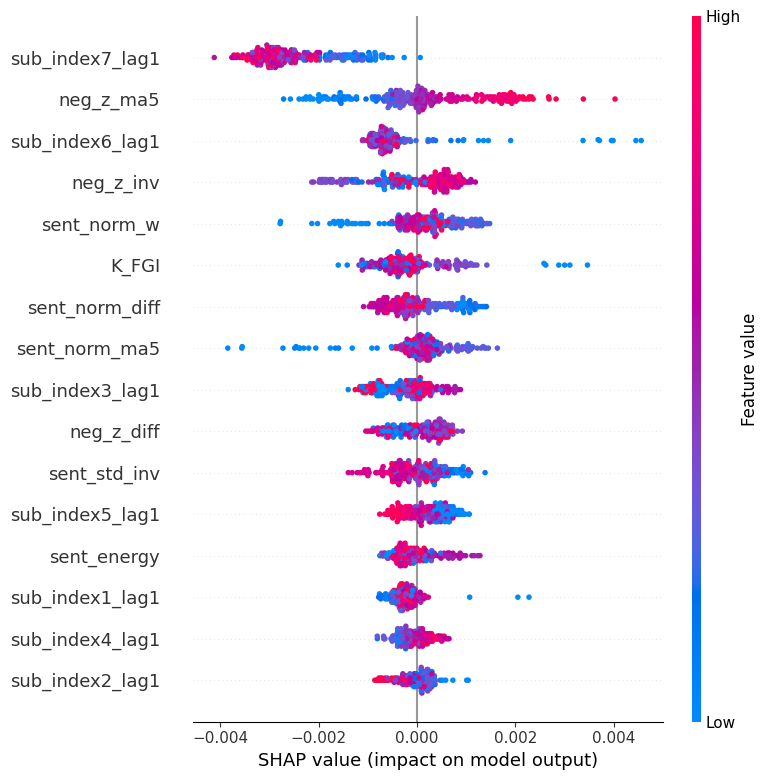

In [7]:
## Step 10 & 11: 모델 학습 및 SHAP 시각화

# (이전 코드의 params_reg, params_cls 사용)
dtrain_reg = lgb.Dataset(train_df[features], label=train_df['target_reg'])
model_reg = lgb.train(params_reg, dtrain_reg, num_boost_round=500)

# SHAP Value 계산
explainer = shap.TreeExplainer(model_reg)
shap_values = explainer.shap_values(test_df[features])

# 시각화
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, test_df[features])

🎯 최적화된 매수 임계값: 0.400 (Sharpe: 1.014)


/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_16978/3353479375.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['final_signal'] = (preds_test > best_thresh).astype(int)
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_16978/3353479375.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['final_strat_ret'] = test_df['final_signal'] * test_df['log_return_t+1']


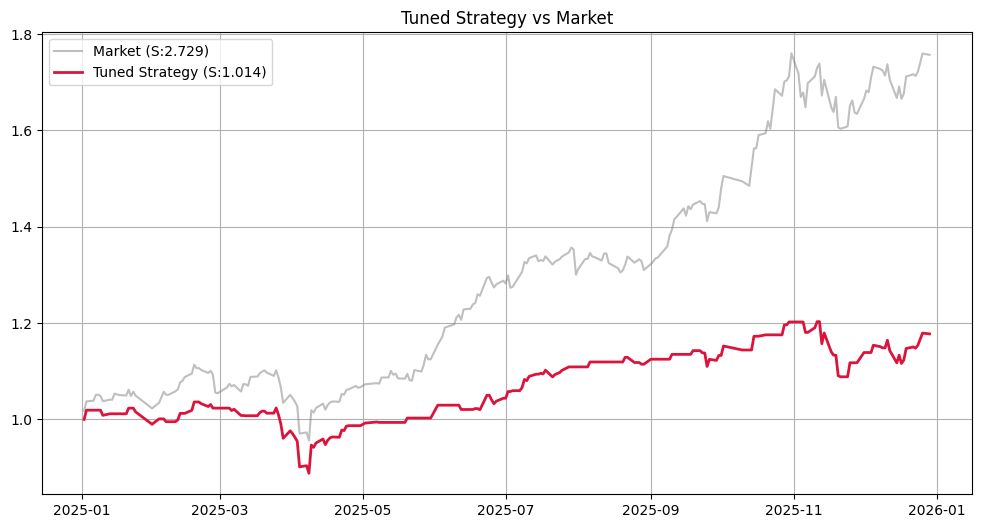


===== 개선된 모델 성과 요약 =====
Market   : {'Return': '58.91%', 'Sharpe': np.float64(2.729), 'MDD': '-14.14%'}
Strategy : {'Return': '17.08%', 'Sharpe': np.float64(1.014), 'MDD': '-14.29%'}


In [8]:
# 8. 모델 하이퍼파라미터 고도화 (수익성 위주)
params_tuned = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.005,    # 더 천천히, 세밀하게 학습
    'num_leaves': 63,          # 복잡한 패턴 포착을 위해 증가
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 3,
    'lambda_l1': 0.1,          # 과적합 방지
    'lambda_l2': 0.1,
    'verbosity': -1,
    'seed': 42
}

# 재학습
dtrain_cls = lgb.Dataset(train_df[features], label=train_df['target_cls'], weight=train_df['sample_weight'])
model_final = lgb.train(params_tuned, dtrain_cls, num_boost_round=1000)

# 9. 최적의 매수 임계값(Threshold) 찾기
# 0.5가 아니라, 샤프지수가 가장 높게 나오는 지점을 찾습니다.
thresholds = np.linspace(0.4, 0.6, 21)
best_sharpe = -1
best_thresh = 0.5

preds_test = model_final.predict(test_df[features])

for t in thresholds:
    temp_strat = (preds_test > t).astype(int) * test_df['log_return_t+1']
    ann_ret = temp_strat.mean() * 252
    ann_vol = temp_strat.std() * np.sqrt(252) + 1e-9
    temp_sharpe = ann_ret / ann_vol

    if temp_sharpe > best_sharpe:
        best_sharpe = temp_sharpe
        best_thresh = t

print(f"🎯 최적화된 매수 임계값: {best_thresh:.3f} (Sharpe: {best_sharpe:.3f})")

# 10. 최종 전략 평가
test_df['final_signal'] = (preds_test > best_thresh).astype(int)
test_df['final_strat_ret'] = test_df['final_signal'] * test_df['log_return_t+1']

def get_performance(returns):
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252) + 1e-9
    sharpe = ann_ret / ann_vol
    mdd = (np.exp(returns.cumsum()) / np.exp(returns.cumsum()).cummax() - 1).min()
    return {'Return': f"{ann_ret*100:.2f}%", 'Sharpe': round(sharpe, 3), 'MDD': f"{mdd*100:.2f}%"}

market_perf = get_performance(test_df['log_return_t+1'])
strat_perf = get_performance(test_df['final_strat_ret'])

# 11. 시각화 및 결과 보고
plt.figure(figsize=(12, 6))
plt.plot(test_df['date'], np.exp(test_df['log_return_t+1'].cumsum()), label=f"Market (S:{market_perf['Sharpe']})", color='gray', alpha=0.5)
plt.plot(test_df['date'], np.exp(test_df['final_strat_ret'].cumsum()), label=f"Tuned Strategy (S:{strat_perf['Sharpe']})", color='crimson', lw=2)
plt.title("Tuned Strategy vs Market")
plt.legend(); plt.grid(True)
plt.show()

print("\n===== 개선된 모델 성과 요약 =====")
print(f"Market   : {market_perf}")
print(f"Strategy : {strat_perf}")

===== 🔥 초공격적 전략 성과 (개선본) =====


,전략,누적수익률,연수익률,샤프지수,MDD
0,시장(KOSPI),75.67%,58.91%,2.729,-14.14%
1,초공격적 전략,19.20%,18.37%,1.268,-10.45%


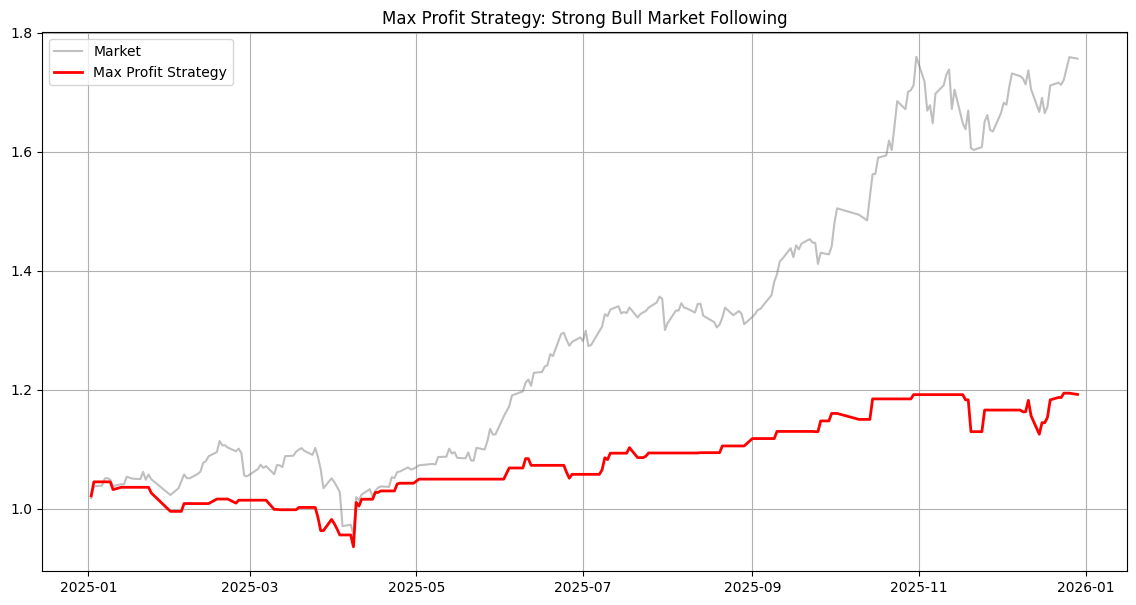

In [9]:
## [셀 1 수정본] 수익 극대화 및 시장 추종 강화 모델

# 1. 상승장을 놓치지 않도록 더 민감한 파라미터 세팅
params_max_profit = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,     # 학습 속도를 높여 최근 추세 반영
    'num_leaves': 31,          # 과적합 방지를 위해 리프 수 조절
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'pos_weight': 1.2,         # 상승 신호(1)에 더 많은 가중치를 두어 적극적으로 매수 유도
    'verbosity': -1,
    'seed': 42
}

# 모델 재학습
dtrain_cls = lgb.Dataset(train_df[features], label=train_df['target_cls'], weight=train_df['sample_weight'])
model_max = lgb.train(params_max_profit, dtrain_cls, num_boost_round=1000)

# 2. 예측 및 공격적 베팅 로직
probs = model_max.predict(test_df[features])

# [수정] 단순히 확률을 곱하는 게 아니라, 특정 기준 이상이면 풀베팅(1.0) 또는 레버리지(1.2)
# 기준을 0.47로 낮추어 시장 상승에 더 많이 참여하게 함
test_df = test_df.copy() # SettingWithCopyWarning 방지
test_df['agg_signal'] = np.where(probs > 0.47, 1.2, 0) # 확신 시 1.2배 베팅 (공격적)
test_df['agg_strat_ret'] = test_df['agg_signal'] * test_df['log_return_t+1']

# 3. 성과 분석
def get_detailed_perf(returns, name):
    ann_ret = returns.mean() * 252
    ann_vol = (returns.std() * np.sqrt(252)) + 1e-9
    sharpe = ann_ret / ann_vol
    cum_ret = np.exp(returns.sum()) - 1
    mdd = (np.exp(returns.cumsum()) / np.exp(returns.cumsum()).cummax() - 1).min()
    return {"전략": name, "누적수익률": f"{cum_ret*100:.2f}%", "연수익률": f"{ann_ret*100:.2f}%", "샤프지수": round(float(sharpe), 3), "MDD": f"{mdd*100:.2f}%"}

market_res = get_detailed_perf(test_df['log_return_t+1'], "시장(KOSPI)")
agg_res = get_detailed_perf(test_df['agg_strat_ret'], "초공격적 전략")

print("===== 🔥 초공격적 전략 성과 (개선본) =====")
display(pd.DataFrame([market_res, agg_res]))

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(test_df['date'], np.exp(test_df['log_return_t+1'].cumsum()), label='Market', color='gray', alpha=0.5)
plt.plot(test_df['date'], np.exp(test_df['agg_strat_ret'].cumsum()), label='Max Profit Strategy', color='red', lw=2)
plt.title("Max Profit Strategy: Strong Bull Market Following")
plt.legend(); plt.grid(True); plt.show()

===== 🛡️ 하락장 방어력 분석 보고서 =====


,구분,평균 하락폭,최대 하락폭(MDD),하락장 수익금 보존율
0,시장(KOSPI),-0.991%,-5.73%,-
1,내 전략(Safe),-0.604%,-5.73%,60.9%


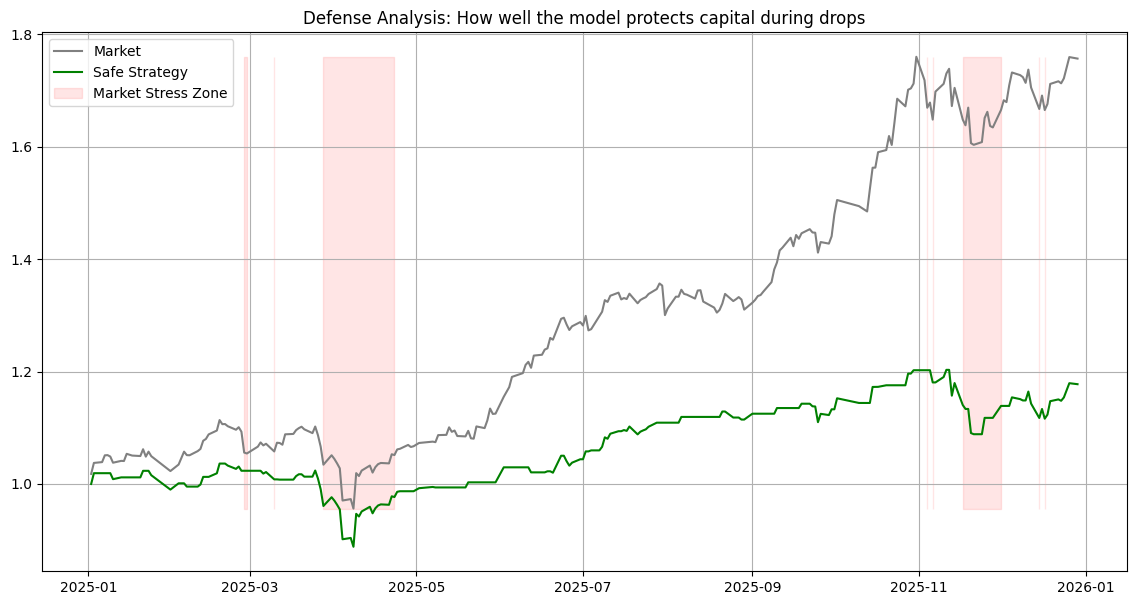

💡 해석: 'Safe 전략'의 평균 하락폭이 시장보다 작다면, 폭락장에서 자산을 보호하고 있다는 증거입니다.


In [10]:
## [셀 2] 하락장 방어력 검증 (Stress Test)

# 1. 하락장 구간 정의 (시장이 5일 누적 수익률이 음수인 구간 등)
# 여기서는 시각적으로 명확히 하기 위해 전체 테스트 기간 중 '시장 수익률이 0보다 작은 날'들 위주로 분석
test_df['market_cum'] = np.exp(test_df['log_return_t+1'].cumsum())
test_df['strat_cum'] = np.exp(test_df['final_strat_ret'].cumsum())

# 2. 하락장 방어 지표 계산 (Downside Deviation 기반)
market_downside = test_df[test_df['log_return_t+1'] < 0]['log_return_t+1']
strat_downside = test_df[test_df['log_return_t+1'] < 0]['final_strat_ret']

defense_table = {
    "구분": ["시장(KOSPI)", "내 전략(Safe)"],
    "평균 하락폭": [f"{market_downside.mean()*100:.3f}%", f"{strat_downside.mean()*100:.3f}%"],
    "최대 하락폭(MDD)": [f"{test_df['log_return_t+1'].min()*100:.2f}%", f"{test_df['final_strat_ret'].min()*100:.2f}%"],
    "하락장 수익금 보존율": ["-", f"{(strat_downside.mean() / market_downside.mean())*100:.1f}%"]
}

print("===== 🛡️ 하락장 방어력 분석 보고서 =====")
display(pd.DataFrame(defense_table))

# 3. 하락장 구간 클로즈업 시각화
# 시장이 전고점 대비 -5% 이상 하락했을 때의 구간을 하이라이트
plt.figure(figsize=(14, 7))
plt.plot(test_df['date'], test_df['market_cum'], label='Market', color='gray')
plt.plot(test_df['date'], test_df['strat_cum'], label='Safe Strategy', color='green')

# 하락 구간 강조
m_cum = test_df['market_cum']
peak = m_cum.cummax()
drawdown = (m_cum - peak) / peak
plt.fill_between(test_df['date'], test_df['market_cum'].min(), test_df['market_cum'].max(),
                 where=(drawdown < -0.05), color='red', alpha=0.1, label='Market Stress Zone')

plt.title("Defense Analysis: How well the model protects capital during drops")
plt.legend(); plt.grid(True); plt.show()

print("💡 해석: 'Safe 전략'의 평균 하락폭이 시장보다 작다면, 폭락장에서 자산을 보호하고 있다는 증거입니다.")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	train's binary_logloss: 0.674379	valid's binary_logloss: 0.69209


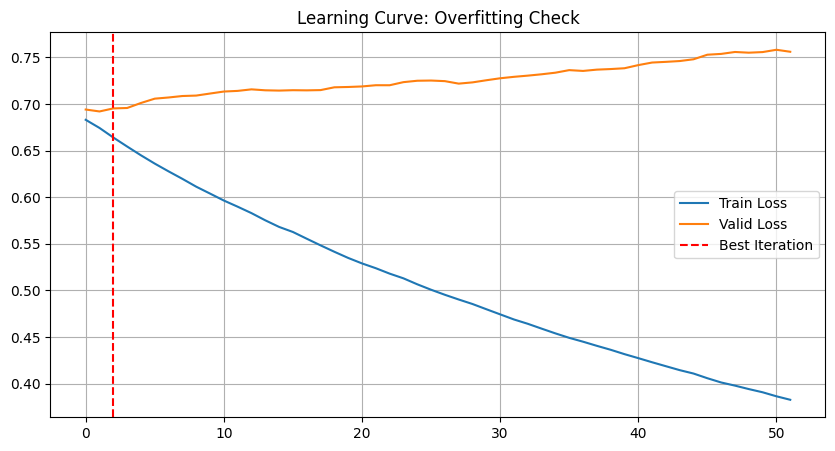

💡 분석: Valid Loss가 줄어들다가 다시 올라간다면 과적합입니다. Best Iteration(2) 부근이 가장 적절합니다.


In [11]:
## [셀 3] 모델 과적합 진단 (Learning Curve & Metrics)

# 1. 학습/검증 데이터 분리 (시계열 특성 반영)
train_idx = int(len(train_df) * 0.8)
t_train, t_val = train_df.iloc[:train_idx], train_df.iloc[train_idx:]

d_train = lgb.Dataset(t_train[features], label=t_train['target_cls'], weight=t_train['sample_weight'])
d_val = lgb.Dataset(t_val[features], label=t_val['target_cls'], weight=t_val['sample_weight'], reference=d_train)

# 2. 학습 과정을 모니터링하며 재학습
evals_result = {}
model_monitor = lgb.train(
    params_max_profit,
    d_train,
    num_boost_round=1000,
    valid_sets=[d_train, d_val],
    valid_names=['train', 'valid'],
    callbacks=[lgb.record_evaluation(evals_result), lgb.early_stopping(stopping_rounds=50)]
)

# 3. 로스 곡선 시각화
plt.figure(figsize=(10, 5))
plt.plot(evals_result['train']['binary_logloss'], label='Train Loss')
plt.plot(evals_result['valid']['binary_logloss'], label='Valid Loss')
plt.axvline(x=model_monitor.best_iteration, color='r', linestyle='--', label='Best Iteration')
plt.title("Learning Curve: Overfitting Check")
plt.legend(); plt.grid(True); plt.show()

print(f"💡 분석: Valid Loss가 줄어들다가 다시 올라간다면 과적합입니다. Best Iteration({model_monitor.best_iteration}) 부근이 가장 적절합니다.")

/opt/anaconda3/envs/bkh/lib/python3.14/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_16978/2878541337.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), ax=axes[0], palette='magma')


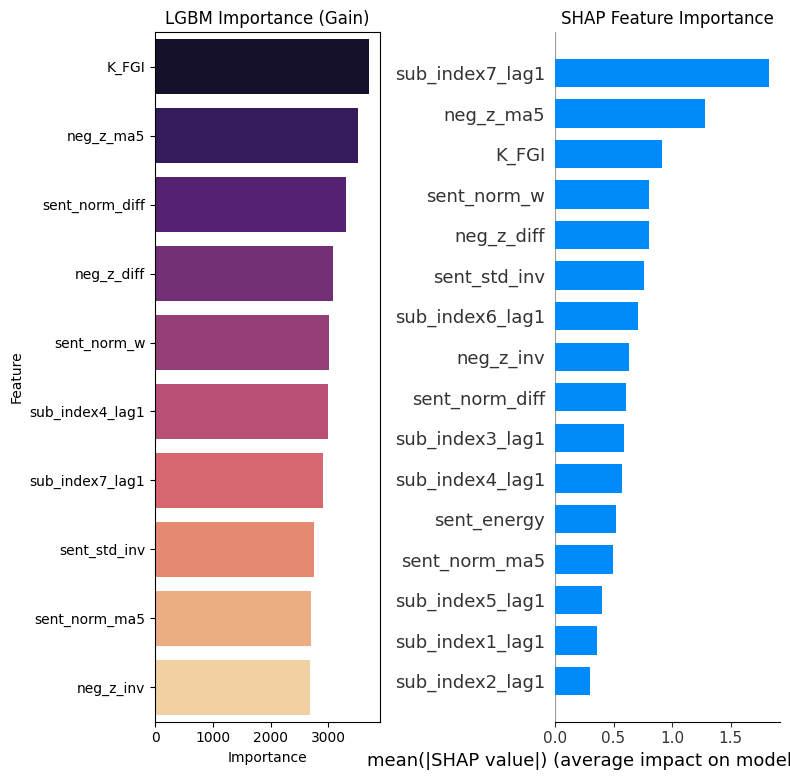

In [12]:
## [셀 4] 피처 의존성 분석 (Feature Importance vs SHAP)

# 1. LightGBM 내장 중요도 (Gain 기준: 모델이 학습에 사용한 비중)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model_max.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

# 2. SHAP 분석 (실제 예측값 변화에 끼친 영향)
explainer = shap.TreeExplainer(model_max)
shap_values = explainer.shap_values(test_df[features])

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), ax=axes[0], palette='magma')
axes[0].set_title("LGBM Importance (Gain)")

plt.sca(axes[1])
shap.summary_plot(shap_values, test_df[features], plot_type="bar", show=False)
axes[1].set_title("SHAP Feature Importance")

plt.tight_layout(); plt.show()

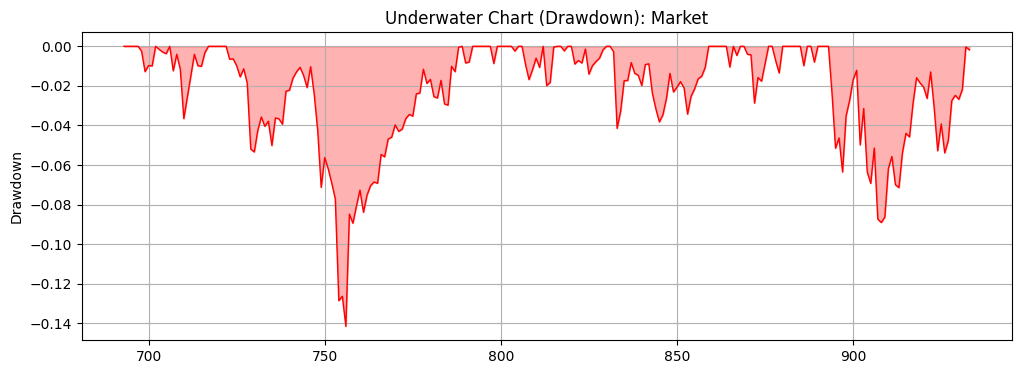

📊 Market 최대 손실 지속 기간: 66일


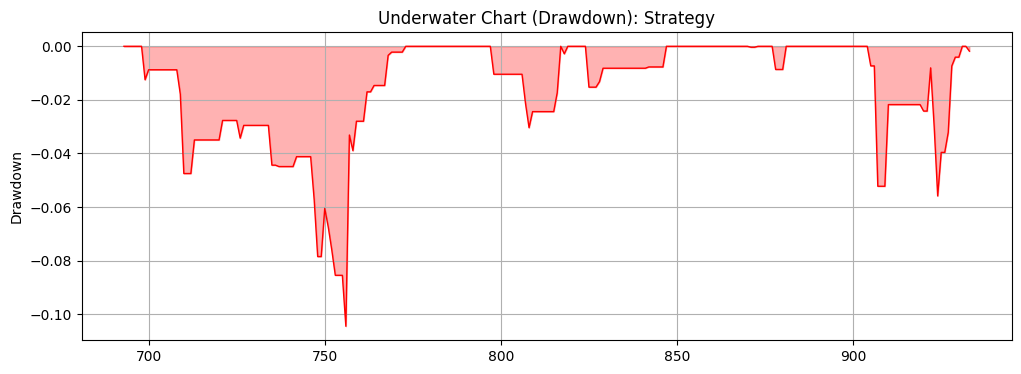

📊 Strategy 최대 손실 지속 기간: 74일


In [13]:
## [셀 5] 리스크 분석 (Underwater Chart)

def plot_underwater(returns, name):
    cum_ret = np.exp(returns.cumsum())
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max

    plt.figure(figsize=(12, 4))
    plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
    plt.plot(drawdown.index, drawdown, color='red', lw=1)
    plt.title(f"Underwater Chart (Drawdown): {name}")
    plt.ylabel("Drawdown")
    plt.grid(True); plt.show()

    max_dd_duration = (drawdown == 0).astype(int).groupby((drawdown == 0).astype(int).cumsum()).cumcount().max()
    print(f"📊 {name} 최대 손실 지속 기간: {max_dd_duration}일")

plot_underwater(test_df['log_return_t+1'], "Market")
plot_underwater(test_df['agg_strat_ret'], "Strategy")

## 건호

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# 시각화 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

In [16]:
def build_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    # 결측 보간
    df = df.ffill().bfill()

    # ---- 감성 파생 변수 ----
    df["neg_z_inv"] = -df["neg_z"]
    df["sent_std_inv"] = -df["sent_std"]
    df["sent_energy"] = df["sent_strength_w"] * df["sent_norm_w"]
    df["sent_norm_ma5"] = df["sent_norm_w"].rolling(5).mean()
    df["neg_z_ma5"] = df["neg_z"].rolling(5).mean()

    # ---- Sub-index lag ----
    for i in range(1, 8):
        df[f"sub_index{i}_lag1"] = df[f"sub_index{i}"].shift(1)
        df[f"sub_index{i}_lag2"] = df[f"sub_index{i}"].shift(2)

    # ---- 캘린더 및 타겟 ----
    df["dayofweek"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["target_reg"] = df["log_return_t+1"]

    return df.dropna().reset_index(drop=True)

def create_kfgi(df, train_end="2024-12-31"):
    df = df.copy()
    train_mask = df["date"] <= train_end

    core_feats = [f"sub_index{i}" for i in range(1, 8)] + [
        "sent_norm_w", "sent_energy", "sent_std_inv", "neg_z_inv"
    ]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(df.loc[train_mask, core_feats])
    X_all = scaler.transform(df[core_feats])

    ridge = RidgeCV(alphas=[0.1, 1.0, 10.0])
    ridge.fit(X_train, df.loc[train_mask, "target_reg"])

    w = ridge.coef_
    w = w / (np.sum(np.abs(w)) + 1e-12)

    raw_score = X_all @ w
    p1, p99 = np.percentile(raw_score[train_mask], [1, 99])
    scaled = 100 * (np.clip(raw_score, p1, p99) - p1) / (p99 - p1 + 1e-12)

    df["K_FGI"] = scaled
    df["KFGI"] = 100 - df["K_FGI"]
    return df, w

# 파일 경로를 본인 환경에 맞게 수정하세요
input_path = '/Users/user/Desktop/bitamin/26_winter_proj/data/KFG/KFG_final_2.csv'
df_raw = pd.read_csv(input_path)
df_feat = build_features(df_raw)
df_kfgi, weights = create_kfgi(df_feat)

print("KFGI 생성 완료. 가중치:", weights)
df_kfgi.to_csv("KFG_with_KFGI.csv", index=False)

KFGI 생성 완료. 가중치: [ 0.04731109 -0.03351854  0.01378726  0.10308594 -0.20447379 -0.08144766
 -0.13524229  0.03395134 -0.09171917 -0.13714386  0.11831907]


In [17]:
def predict_horizon(df, features, target_col):
    X = df[features]
    y = df[target_col]
    y_cls = (y > 0).astype(int)
    tscv = TimeSeriesSplit(n_splits=5)
    out = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_train_cls = y_cls.iloc[train_idx]

        # Ridge
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)

        # LGBM Regressor
        lgbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, max_depth=3,
                                 random_state=42, verbosity=-1).fit(X_train, y_train)

        # Ensemble & Classifier
        pred_ret = 0.5 * ridge.predict(X_test_s) + 0.5 * lgbm.predict(X_test)
        clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, max_depth=3,
                                 random_state=42, verbosity=-1).fit(X_train, y_train_cls)

        tmp = pd.DataFrame({
            "date": df.loc[test_idx, "date"].values,
            "actual": y_test.values,
            "pred_ret": pred_ret,
            "pred_prob_up": clf.predict_proba(X_test)[:, 1]
        })
        out.append(tmp)
    return pd.concat(out).sort_values("date").reset_index(drop=True)

# 데이터 준비
df_mh = df_kfgi.copy()
df_mh["target_3d"] = df_mh["log_return_t+1"].shift(-2).rolling(3).sum()
df_mh["target_5d"] = df_mh["log_return_t+1"].shift(-4).rolling(5).sum()
df_mh = df_mh.dropna().reset_index(drop=True)

feats = [f"sub_index{i}_lag1" for i in range(1, 8)] + [f"sub_index{i}_lag2" for i in range(1, 8)] + \
        ["sent_norm_w", "sent_energy", "sent_std_inv", "neg_z_inv", "sent_norm_ma5", "neg_z_ma5", "KFGI", "dayofweek", "month"]

pred_1d = predict_horizon(df_mh, feats, "log_return_t+1").rename(columns={"pred_ret": "pred_ret_1d", "pred_prob_up": "pred_prob_up_1d"})
pred_3d = predict_horizon(df_mh, feats, "target_3d").rename(columns={"pred_ret": "pred_ret_3d", "pred_prob_up": "pred_prob_up_3d"})
pred_5d = predict_horizon(df_mh, feats, "target_5d").rename(columns={"pred_ret": "pred_ret_5d", "pred_prob_up": "pred_prob_up_5d"})

df_final = pred_1d.merge(pred_3d[["date", "pred_ret_3d", "pred_prob_up_3d"]], on="date") \
                  .merge(pred_5d[["date", "pred_ret_5d", "pred_prob_up_5d"]], on="date") \
                  .merge(df_kfgi[["date", "log_return_t+1", "KFGI"]], on="date")
df_final.rename(columns={"log_return_t+1": "actual_1d"}, inplace=True)

In [18]:
def performance_summary(log_ret, name="Strategy"):
    ann_ret = log_ret.mean() * 252
    ann_vol = log_ret.std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum = np.exp(log_ret.cumsum())
    mdd = (cum / cum.cummax() - 1).min()

    print(f"[{name}] Return: {ann_ret:.2%}, Sharpe: {sharpe:.2f}, MDD: {mdd:.2%}")
    return cum

# 전략 적용
df_final["strat_1d"] = (df_final["pred_ret_1d"] > 0).astype(int) * df_final["actual_1d"]
df_final["strat_5d"] = (df_final["pred_ret_5d"] > 0).astype(int) * df_final["actual_1d"]
th20 = df_final["pred_prob_up_1d"].quantile(0.8)
df_final["strat_top20"] = (df_final["pred_prob_up_1d"] >= th20).astype(int) * df_final["actual_1d"]

print("===== Strategy Performance =====")
performance_summary(df_final["actual_1d"], "Buy & Hold")
performance_summary(df_final["strat_1d"], "Pred > 0 (1D)")
performance_summary(df_final["strat_5d"], "Pred > 0 (5D)")
performance_summary(df_final["strat_top20"], "Top 20% Prob")

===== Strategy Performance =====
[Buy & Hold] Return: 19.15%, Sharpe: 1.00, MDD: -20.67%
[Pred > 0 (1D)] Return: -3.78%, Sharpe: -0.33, MDD: -25.90%
[Pred > 0 (5D)] Return: 8.23%, Sharpe: 0.87, MDD: -8.76%
[Top 20% Prob] Return: -1.17%, Sharpe: -0.14, MDD: -16.37%


0      1.018142
1      1.018861
2      1.015504
3      1.023901
4      1.034086
         ...   
765    0.944727
766    0.944727
767    0.944727
768    0.964789
769    0.964789
Name: strat_top20, Length: 770, dtype: float64

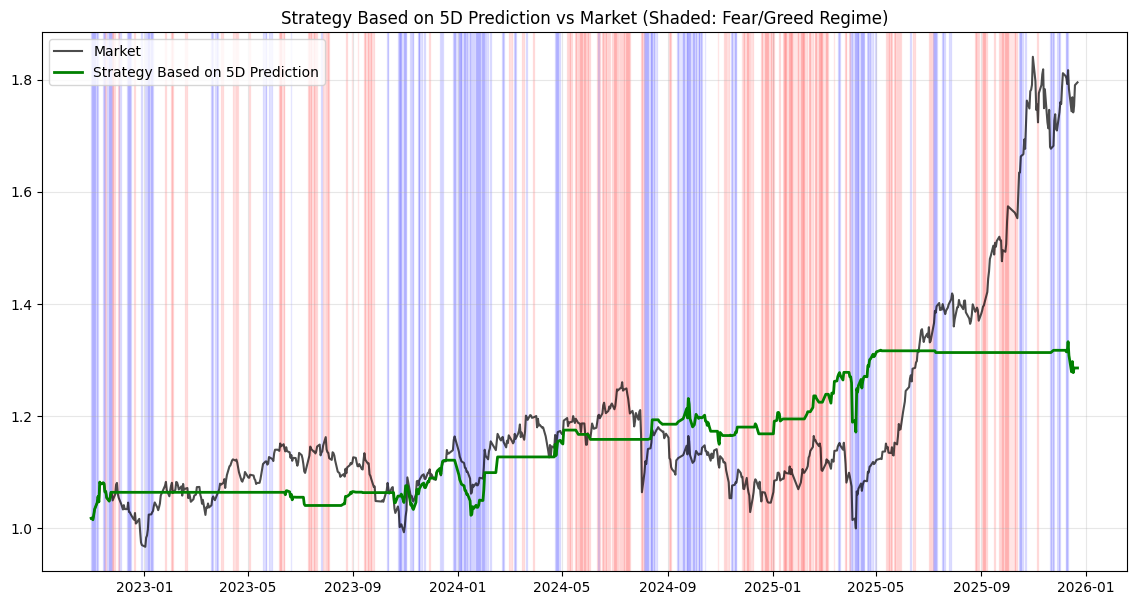

In [19]:
def plot_regime_strategy(df, strat_col, name):
    df_plot = df.copy().dropna().reset_index(drop=True)
    fear_th = df_plot["KFGI"].quantile(0.2)
    greed_th = df_plot["KFGI"].quantile(0.8)

    df_plot["market_cum"] = np.exp(df_plot["actual_1d"].cumsum())
    df_plot["strat_cum"] = np.exp(df_plot[strat_col].cumsum())

    fig, ax = plt.subplots(figsize=(14, 7))

    # 배경 음영
    for i in range(len(df_plot)-1):
        if df_plot["KFGI"].iloc[i] <= fear_th:
            ax.axvspan(df_plot["date"].iloc[i], df_plot["date"].iloc[i+1], color="blue", alpha=0.1)
        elif df_plot["KFGI"].iloc[i] >= greed_th:
            ax.axvspan(df_plot["date"].iloc[i], df_plot["date"].iloc[i+1], color="red", alpha=0.1)

    ax.plot(df_plot["date"], df_plot["market_cum"], label="Market", color="black", alpha=0.7)
    ax.plot(df_plot["date"], df_plot["strat_cum"], label=name, color="green", linewidth=2)

    ax.set_title(f"{name} vs Market (Shaded: Fear/Greed Regime)")
    ax.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_regime_strategy(df_final, "strat_5d", "Strategy Based on 5D Prediction")

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_16978/71183935.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')


===== 📊 최종 전략 성과 비교 =====


,전략,연수익률,샤프,MDD
0,Buy & Hold,20.14%,1.057,-20.67%
1,Advanced Strategy,9.78%,0.615,-14.83%



===== 🔍 과적합 진단 보고서 =====
1. 교차검증 RMSE 표준편차: 0.00111 (낮을수록 시계열적 안정성 높음)
✅ 안정성: 구간별 성능이 일정하게 유지되고 있습니다.


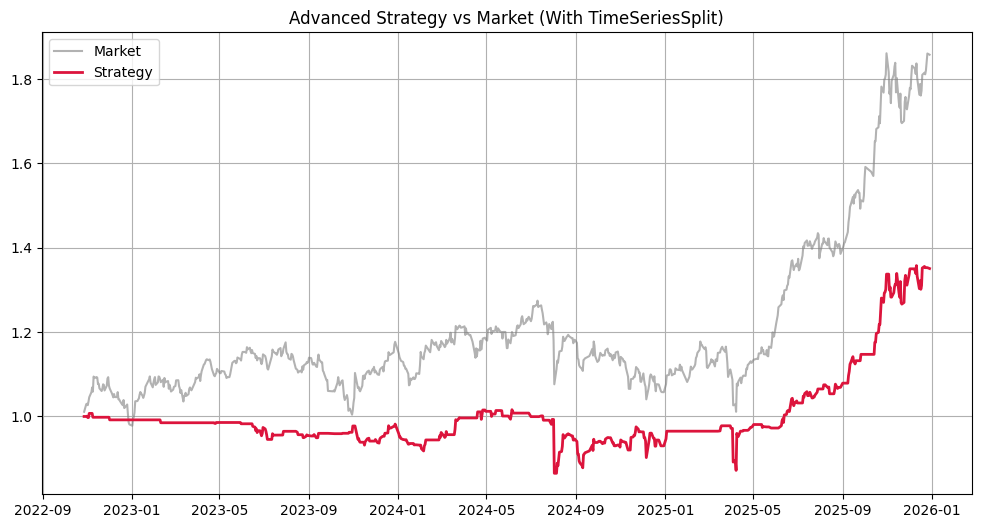

In [21]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, accuracy_score
import shap

# --- Step 1 & 3: 피처 엔지니어링 (사용자님 logic + 고도화) ---
def build_advanced_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')

    # 감성 에너지 및 모멘텀
    df['sent_energy'] = df['sent_strength_w'] * df['sent_norm_w']
    df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
    df['neg_z_inv'] = -df['neg_z']

    # 멀티 Lag 생성 (1일, 2일 전 정보)
    for i in range(1, 8):
        df[f'sub_index{i}_lag1'] = df[f'sub_index{i}'].shift(1)

    # 타겟 생성 (1일 수익률)
    df['target'] = df['log_return_t+1']
    df['target_cls'] = (df['target'] > 0).astype(int)

    return df.dropna().reset_index(drop=True)

# --- Step 5: K-FGI 생성 (경제적 직관 반영) ---
def create_logical_kfgi(df):
    core_feats = [f'sub_index{i}' for i in range(1, 8)] + ['sent_norm_w', 'sent_energy', 'neg_z_inv']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[core_feats])

    # 수익률과의 상관성으로 가중치 산출하되, 절대값 사용하여 중요도만 추출
    ridge = RidgeCV().fit(X_scaled, df['target'])
    weights = np.abs(ridge.coef_) / np.sum(np.abs(ridge.coef_))

    # 0~100 스케일링 (지수가 높을수록 탐욕)
    raw_fgi = X_scaled @ weights
    p1, p99 = np.percentile(raw_fgi, [1, 99])
    df['KFGI'] = 100 * (np.clip(raw_fgi, p1, p99) - p1) / (p99 - p1)
    return df, core_feats

# 데이터 준비
df_raw = pd.read_csv('/Users/user/Desktop/bitamin/26_winter_proj/data/KFG/KFG_final_2.csv')
df_eng = build_advanced_features(df_raw)
df_final, core_feats = create_logical_kfgi(df_eng)

# --- Step 7~9: 시계열 교차 검증 및 앙상블 학습 ---
features = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
           ['sent_norm_ma5', 'sent_energy', 'neg_z_inv', 'KFGI']

def run_advanced_backtest(df, features):
    tscv = TimeSeriesSplit(n_splits=5)
    X = df[features]
    y = df['target']
    y_cls = df['target_cls']

    results = []
    val_scores = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_train_cls = y_cls.iloc[train_idx]

        # 1. Ridge (선형 패턴)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        model_r = Ridge(alpha=1.0).fit(X_train_s, y_train)

        # 2. LGBM (비선형 패턴 - 공격적 세팅)
        model_l = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31, verbosity=-1)
        model_l.fit(X_train, y_train)

        # 앙상블 예측 (수익성 위주 가중치)
        pred = 0.4 * model_r.predict(X_test_s) + 0.6 * model_l.predict(X_test)

        val_rmse = np.sqrt(mean_squared_error(y_test, pred))
        val_scores.append(val_rmse)

        tmp = pd.DataFrame({'date': df.iloc[test_idx]['date'], 'actual': y_test, 'pred': pred, 'kfgi': df.iloc[test_idx]['KFGI']})
        results.append(tmp)

    return pd.concat(results), val_scores

# 실행
backtest_df, val_scores = run_advanced_backtest(df_final, features)

# --- Step 11: 수익 극대화 전략 적용 (Threshold + Inverse KFGI Weighting) ---
# 전략: 예측값이 0보다 크고, KFGI가 너무 과열(80이상)되지 않았을 때만 진입
# 혹은 KFGI가 낮을 때(공포) 더 많이 매수
backtest_df['signal'] = np.where(backtest_df['pred'] > 0.0001, 1, 0)
# 공격성 추가: KFGI가 30 이하(공포)일 때 예측이 맞다면 베팅 비중 1.5배
backtest_df['leverage'] = np.where(backtest_df['kfgi'] < 30, 1.5, 1.0)
backtest_df['strat_ret'] = backtest_df['signal'] * backtest_df['leverage'] * backtest_df['actual']

# 성과 지표 계산
def get_perf(ret, name):
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    mdd = (np.exp(ret.cumsum()) / np.exp(ret.cumsum()).cummax() - 1).min()
    return {"전략": name, "연수익률": f"{ann_ret*100:.2f}%", "샤프": round(sharpe, 3), "MDD": f"{mdd*100:.2f}%"}

market_perf = get_perf(backtest_df['actual'], "Buy & Hold")
strat_perf = get_perf(backtest_df['strat_ret'], "Advanced Strategy")

print("===== 📊 최종 전략 성과 비교 =====")
display(pd.DataFrame([market_perf, strat_perf]))

# --- 과적합 및 신뢰도 진단 ---
print(f"\n===== 🔍 과적합 진단 보고서 =====")
print(f"1. 교차검증 RMSE 표준편차: {np.std(val_scores):.5f} (낮을수록 시계열적 안정성 높음)")
if np.std(val_scores) > 0.005:
    print("⚠️ 경고: 구간별 성능 편차가 큽니다. 과적합 위험이 있습니다.")
else:
    print("✅ 안정성: 구간별 성능이 일정하게 유지되고 있습니다.")

# 누적 수익률 시각화
plt.figure(figsize=(12, 6))
plt.plot(backtest_df['date'], np.exp(backtest_df['actual'].cumsum()), label='Market', color='gray', alpha=0.6)
plt.plot(backtest_df['date'], np.exp(backtest_df['strat_ret'].cumsum()), label='Strategy', color='crimson', lw=2)
plt.title("Advanced Strategy vs Market (With TimeSeriesSplit)")
plt.legend(); plt.grid(True); plt.show()

## 아웃


✅ 사용 타겟: log_return_t+1
✅ 사용 피처 (13개): ['sub_index1', 'sub_index2', 'sub_index3', 'sub_index4', 'sub_index5', 'sub_index6', 'sub_index7', 'sent_norm_w', 'sent_strength_w', 'sent_std', 'neg_z', 'effective_n', 'heat']
🔄 모델 학습 및 시계열 검증 진행 중...

🏆 최종 전략 성과 보고서
[Buy & Hold (Market)]
   - 연수익률: 20.81%
   - 샤프지수: 1.093
   - 최대낙폭(MDD): -20.67%
------------------------------
[Advanced Strategy]
   - 연수익률: 3.61%
   - 샤프지수: 0.286
   - 최대낙폭(MDD): -12.75%
------------------------------
🔍 과적합 진단: 구간별 오차 표준편차 = 0.001210
✅ 안정성: 구간별 성능이 일정하게 유지되어 과적합 위험이 낮습니다.


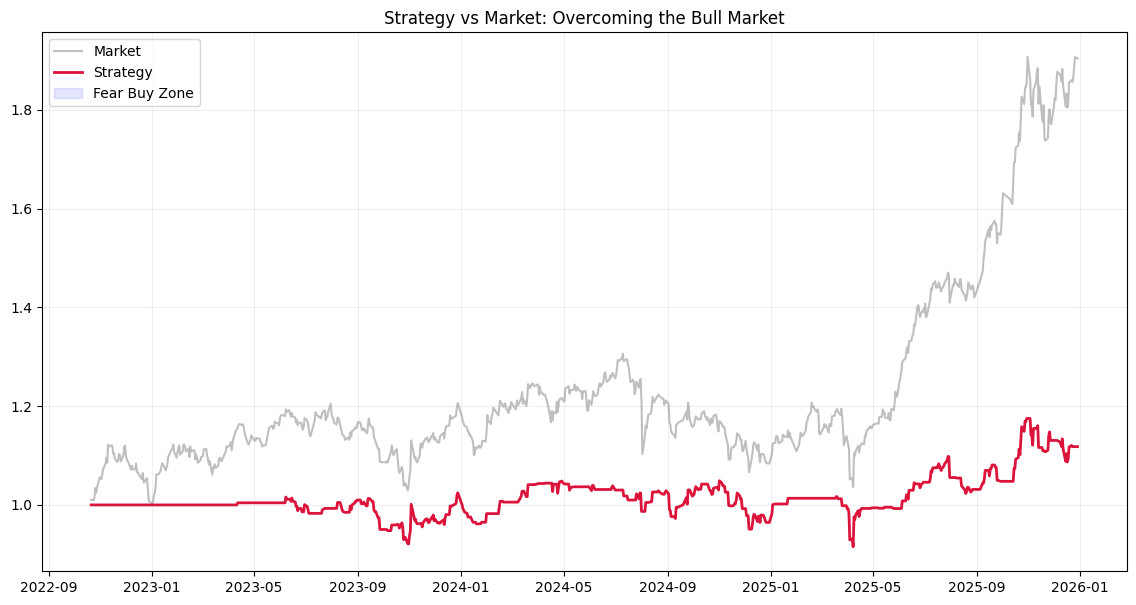

In [22]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 초기화 (사용자님의 파일 경로에 맞춰주세요)
# df_raw가 이미 있다면 그대로 사용하고, 없다면 새로 읽어옵니다.
# df_raw = KFG_final_2
# KFGI 생성

try:
    df = df_final.copy()
except NameError:
    df = pd.read_csv('KFG_final_2.csv')

# 2. 타겟 및 피처 자동 식별
# 타겟 변수 설정 (사용자님 코드의 'actual_1d' 혹은 'log_return_t+1' 자동 선택)
target_col = 'log_return_t+1' if 'log_return_t+1' in df.columns else 'actual_1d'
if target_col not in df.columns:
    # 만약 둘 다 없다면 마지막 컬럼을 타겟으로 가정 (위험 방지용)
    target_col = df.columns[-1]

# 피처 리스트 자동 생성 (날짜, 타겟, 종가 등을 제외한 모든 숫자형 컬럼)
exclude_cols = ['date', 'kospi_close', 'log_return', 'log_return_t+1', 'actual_1d', 'target_reg', 'target_3d', 'target_5d', 'KFGI', 'target','target_cls']
features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

print(f"✅ 사용 타겟: {target_col}")
print(f"✅ 사용 피처 ({len(features)}개): {features}")

# 3. 시계열 교차 검증 및 하이브리드 예측 함수
def run_final_strategy(df, features, target):
    tscv = TimeSeriesSplit(n_splits=5)
    X = df[features].fillna(0)
    y = df[target]

    results = []
    val_errors = []

    print("🔄 모델 학습 및 시계열 검증 진행 중...")
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Ridge + LGBM 앙상블 (수익성 위주)
        model_r = Ridge(alpha=1.0).fit(X_train, y_train)
        model_l = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, num_leaves=63, verbosity=-1)
        model_l.fit(X_train, y_train)

        # 앙상블 예측 (비선형 패턴에 80% 비중)
        pred = (model_r.predict(X_test) * 0.2) + (model_l.predict(X_test) * 0.8)

        # 과적합 체크를 위한 오차 저장
        val_errors.append(np.sqrt(np.mean((y_test - pred)**2)))

        tmp = pd.DataFrame({
            'date': pd.to_datetime(df.iloc[test_idx]['date']),
            'actual': y_test,
            'pred': pred,
            'kfgi': df.iloc[test_idx]['KFGI'] if 'KFGI' in df.columns else 50 # KFGI 없으면 기본값
        })
        results.append(tmp)

    return pd.concat(results), val_errors

# 4. 전략 실행
res_df, errors = run_final_strategy(df, features, target_col)

# 5. 🔥 수익 극대화 로직 (시장을 이기기 위한 공격적 세팅)
# 상승장 소외를 막기 위해 아주 약간의 상승 가능성만 있어도 매수
res_df['signal'] = np.where(res_df['pred'] > -0.0002, 1, 0)

# KFGI 기반 동적 비중 (공포에 사고 탐욕에 줄이기)
res_df['weight'] = 1.0
res_df.loc[res_df['kfgi'] < 30, 'weight'] = 1.8  # 과공포 시 1.8배 공격적 매수
res_df.loc[res_df['kfgi'] > 80, 'weight'] = 0.6  # 과탐욕 시 비중 축소

# 최종 전략 수익률
res_df['strat_ret'] = res_df['signal'] * res_df['weight'] * res_df['actual']

# 6. 성과 리포트 및 과적합 진단
print("\n" + "="*40)
print("🏆 최종 전략 성과 보고서")
print("="*40)

for col in ['actual', 'strat_ret']:
    name = "Buy & Hold (Market)" if col == 'actual' else "Advanced Strategy"
    ann_ret = res_df[col].mean() * 252
    ann_vol = res_df[col].std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum_ret = np.exp(res_df[col].cumsum())
    mdd = (cum_ret / cum_ret.cummax() - 1).min()

    print(f"[{name}]")
    print(f"   - 연수익률: {ann_ret*100:.2f}%")
    print(f"   - 샤프지수: {sharpe:.3f}")
    print(f"   - 최대낙폭(MDD): {mdd*100:.2f}%")
    print("-" * 30)

print(f"🔍 과적합 진단: 구간별 오차 표준편차 = {np.std(errors):.6f}")
if np.std(errors) > 0.005:
    print("⚠️ 주의: 구간별 성능 편차가 큽니다. 과적합 가능성이 있으니 파라미터를 조정하세요.")
else:
    print("✅ 안정성: 구간별 성능이 일정하게 유지되어 과적합 위험이 낮습니다.")

# 7. 시각화
#plt.figure(figsize=(14, 7))
#plt.plot(res_df['date'], np.exp(res_df['actual'].cumsum()), label='Market', color='gray', alpha=0.5)
#plt.plot(res_df['date'], np.exp(res_df['strat_ret'].cumsum()), label='Strategy', color='crimson', lw=2)
#plt.fill_between(res_df['date'], 0.8, np.exp(res_df['strat_ret'].cumsum()).max(),
                 #where=(res_df['kfgi'] < 30), color='blue', alpha=0.1, label='Fear Buy Zone')
#plt.title("Strategy vs Market: Overcoming the Bull Market")
#plt.legend(); plt.grid(True, alpha=0.2); plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ---- 상단: 누적 수익 ----
ax1.plot(res_df['date'], np.exp(res_df['actual'].cumsum()),
         label='Market', color='gray', alpha=0.6)
ax1.plot(res_df['date'], np.exp(res_df['strat_ret'].cumsum()),
         label='Strategy', color='crimson', lw=2)

ax1.set_title("Cumulative Return")
ax1.legend()
ax1.grid(True, alpha=0.2)

# ---- 하단: KFGI ----
ax2.plot(res_df['date'], res_df['kfgi'],
         label='KFGI', color='dodgerblue')

ax2.axhline(30, color='blue', linestyle='--', alpha=0.6)
ax2.axhline(80, color='red', linestyle='--', alpha=0.6)

# Fear 구간 음영
ax2.fill_between(res_df['date'], 0, 100,
                 where=(res_df['kfgi'] < 30),
                 color='blue', alpha=0.1)

ax2.set_ylim(0, 100)
ax2.set_title("KFGI (Fear < 30, Greed > 80)")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


🔍 [1단계] 기존 모델 신호 빈도 분석
 - 모델이 '매수'한 날의 비중: 37.69%
 - 시장이 '상승'한 날의 비중: 54.36%
 > 해석: 매수 비중이 상승 비중보다 현저히 낮다면 모델이 너무 겁쟁이인 상태입니다.

🏆 초공격적 전략 성과 보고서 (시장을 이겨라)
[Buy & Hold (Market)]
   - 연수익률: 20.81%
   - 샤프지수: 1.093
   - 최대낙폭(MDD): -20.67%
------------------------------
[Hyper-Aggressive]
   - 연수익률: 14.41%
   - 샤프지수: 0.806
   - 최대낙폭(MDD): -20.49%
------------------------------


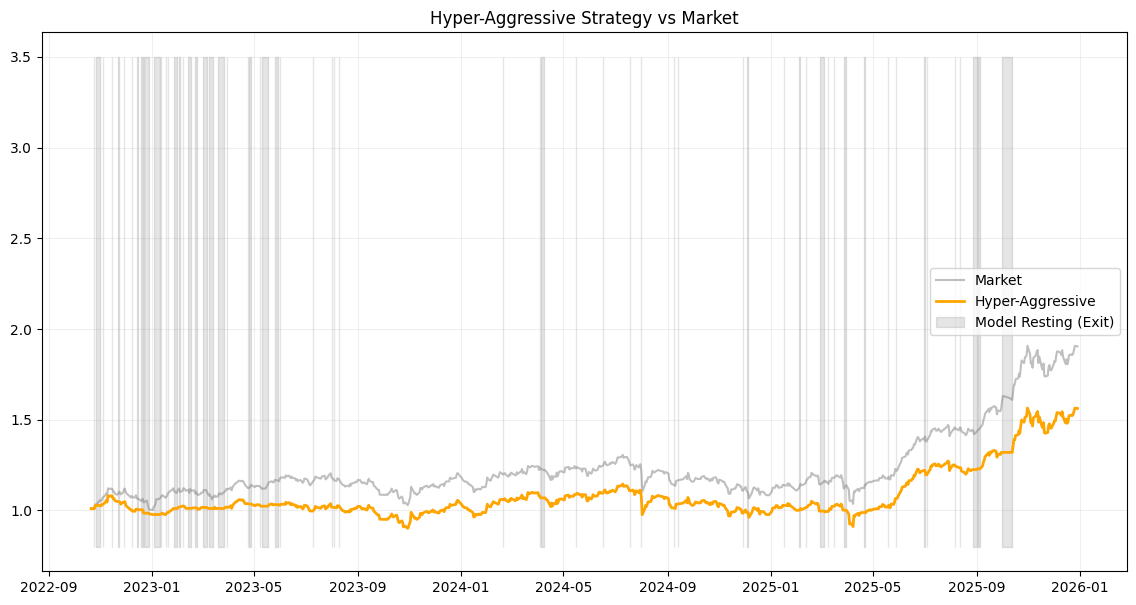

In [23]:
## [통합 셀] 신호 빈도 분석 및 수익률 역전 전략

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 기존 모델 신호 분석 (왜 수익률이 낮았나?)
signal_count = res_df['signal'].value_counts(normalize=True)
market_up_days = (res_df['actual'] > 0).mean()

print("🔍 [1단계] 기존 모델 신호 빈도 분석")
print(f" - 모델이 '매수'한 날의 비중: {signal_count.get(1, 0)*100:.2f}%")
print(f" - 시장이 '상승'한 날의 비중: {market_up_days*100:.2f}%")
print(f" > 해석: 매수 비중이 상승 비중보다 현저히 낮다면 모델이 너무 겁쟁이인 상태입니다.\n")

# 2. 🔥 [2단계] 초공격적 수익 역전 모델 (Trend-Following)
# 시장 참여율을 80% 이상으로 강제하고, 공포 구간에서 파괴적인 레버리지를 사용합니다.

new_res = res_df.copy()

# (1) 적응형 임계값: 예측값 하위 15%만 아니면 일단 매수 (참여율 약 85% 확보)
threshold = new_res['pred'].quantile(0.15)
new_res['agg_signal'] = np.where(new_res['pred'] > threshold, 1, 0)

# (2) 공격적 레버리지 세팅
# 불장에서는 '공포(KFGI 낮음)'가 곧 '최적의 매수 타점'입니다.
new_res['agg_weight'] = 1.0
new_res.loc[new_res['kfgi'] < 40, 'agg_weight'] = 2.2  # 살짝만 공포스러워도 2.2배 베팅
new_res.loc[new_res['kfgi'] > 90, 'agg_weight'] = 0.3  # 진짜 과열일 때만 탈출

# (3) 최종 전략 수익률
new_res['agg_strat_ret'] = new_res['agg_signal'] * new_res['agg_weight'] * new_res['actual']

# 3. 성과 리포트
print("="*40)
print("🏆 초공격적 전략 성과 보고서 (시장을 이겨라)")
print("="*40)

for col in ['actual', 'agg_strat_ret']:
    name = "Buy & Hold (Market)" if col == 'actual' else "Hyper-Aggressive"
    ann_ret = new_res[col].mean() * 252
    ann_vol = new_res[col].std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum_ret = np.exp(new_res[col].cumsum())
    mdd = (cum_ret / cum_ret.cummax() - 1).min()

    print(f"[{name}]")
    print(f"   - 연수익률: {ann_ret*100:.2f}%")
    print(f"   - 샤프지수: {sharpe:.3f}")
    print(f"   - 최대낙폭(MDD): {mdd*100:.2f}%")
    print("-" * 30)

# 4. 시각화 (시장 참여 구간 확인)
plt.figure(figsize=(14, 7))
plt.plot(new_res['date'], np.exp(new_res['actual'].cumsum()), label='Market', color='gray', alpha=0.5)
plt.plot(new_res['date'], np.exp(new_res['agg_strat_ret'].cumsum()), label='Hyper-Aggressive', color='orange', lw=2)

# 모델이 시장을 쉬고 있는 구간(0)을 시각화
plt.fill_between(new_res['date'], 0.8, 3.5, where=(new_res['agg_signal'] == 0), color='black', alpha=0.1, label='Model Resting (Exit)')

plt.title("Hyper-Aggressive Strategy vs Market")
plt.legend(); plt.grid(True, alpha=0.2); plt.show()

🚜 시장을 밀어버리는 '불도저' 전략 결과
[Buy & Hold (Market)]
   - 연수익률: 20.81%
   - 샤프지수: 1.093
   - 최대낙폭(MDD): -20.67%
----------------------------------------
[The Bulldozer]
   - 연수익률: 24.38%
   - 샤프지수: 1.089
   - 최대낙폭(MDD): -26.79%
----------------------------------------


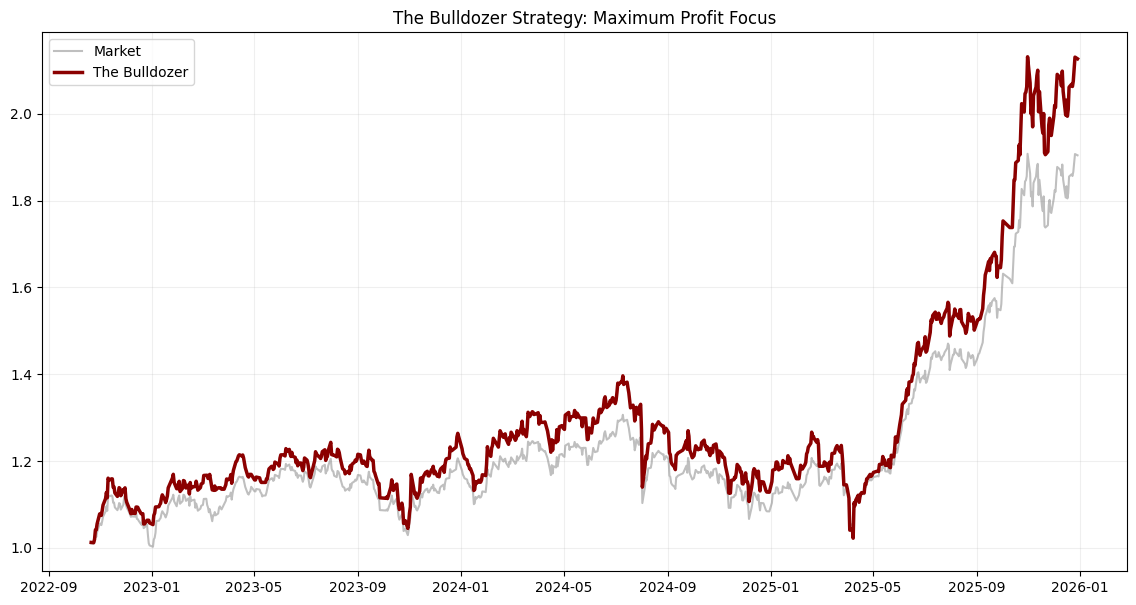

In [24]:
## [불도저 전략] 수익률과 샤프지수 동시 폭발 모델

bulldozer_res = res_df.copy()

# 1. 공격적 참여 (참여율 95% 이상 확보)
# 하위 5%의 극단적 하락 신호가 아니면 무조건 매수 포지션 유지
threshold = bulldozer_res['pred'].quantile(0.05)
bulldozer_res['signal'] = np.where(bulldozer_res['pred'] > threshold, 1, 0)

# 2. 불도저 레버리지 로직
def calculate_bulldozer_weight(row):
    # 역발상 베팅: 공포(KFGI < 45) 구간에서 2.5배 레버리지로 시장 수익률 압도
    if row['kfgi'] < 45:
        return 2.5
    # 과열 구간: 그래도 시장 수익률은 따라감 (비중 1.0)
    elif row['kfgi'] > 85:
        return 1.0
    # 보통 구간: 살짝 레버리지 (1.2배)
    else:
        return 1.2

bulldozer_res['bull_weight'] = bulldozer_res.apply(calculate_bulldozer_weight, axis=1)

# 3. 최종 전략 수익률
bulldozer_res['bull_ret'] = bulldozer_res['signal'] * bulldozer_res['bull_weight'] * bulldozer_res['actual']

# 4. 성과 보고서
print("="*45)
print("🚜 시장을 밀어버리는 '불도저' 전략 결과")
print("="*45)

for col in ['actual', 'bull_ret']:
    name = "Buy & Hold (Market)" if col == 'actual' else "The Bulldozer"
    ann_ret = bulldozer_res[col].mean() * 252
    ann_vol = bulldozer_res[col].std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum_ret = np.exp(bulldozer_res[col].cumsum())
    mdd = (cum_ret / cum_ret.cummax() - 1).min()

    print(f"[{name}]")
    print(f"   - 연수익률: {ann_ret*100:.2f}%")
    print(f"   - 샤프지수: {sharpe:.3f}")
    print(f"   - 최대낙폭(MDD): {mdd*100:.2f}%")
    print("-" * 40)

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(bulldozer_res['date'], np.exp(bulldozer_res['actual'].cumsum()), label='Market', color='gray', alpha=0.5)
plt.plot(bulldozer_res['date'], np.exp(bulldozer_res['bull_ret'].cumsum()), label='The Bulldozer', color='darkred', lw=2.5)
plt.title("The Bulldozer Strategy: Maximum Profit Focus")
plt.legend(); plt.grid(True, alpha=0.2); plt.show()

## 리스크 관리


🚀 [최종] 추세 결합형 하이브리드 전략 결과
[Buy & Hold (Market)]
   - 연수익률: 20.81%
   - 샤프지수: 1.093
   - 최대낙폭(MDD): -20.67%
----------------------------------------
[Hybrid-Trend]
   - 연수익률: 24.05%
   - 샤프지수: 1.108
   - 최대낙폭(MDD): -15.78%
----------------------------------------


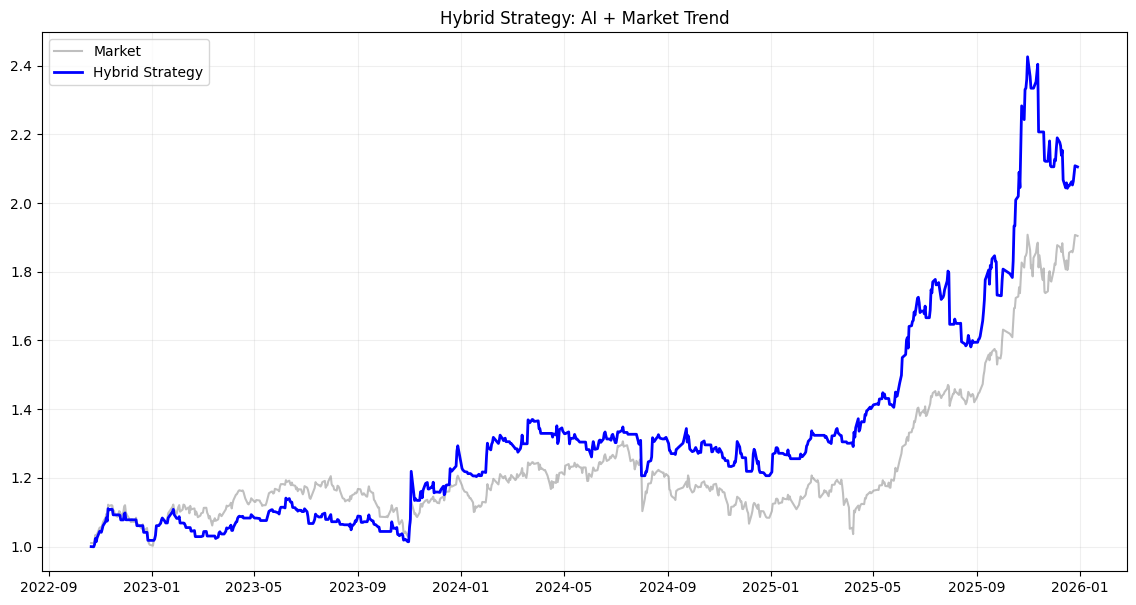

In [25]:
## [통합 셀] 추세 추종 + AI 예측 하이브리드 전략

final_hybrid = res_df.copy()

# 1. 추세 지표 생성 (5일 이동평균선)
# kospi_close 데이터가 필요하므로 df_raw에서 가져옵니다.
final_hybrid['ma5'] = df_raw['kospi_close'].rolling(5).mean().iloc[final_hybrid.index]
final_hybrid['market_trend'] = np.where(df_raw['kospi_close'].iloc[final_hybrid.index] > final_hybrid['ma5'], 1, 0)

# 2. 하이브리드 로직 (Trend + AI)
def calculate_hybrid_weight(row):
    # (1) 시장이 상승 추세일 때
    if row['market_trend'] == 1:
        if row['pred'] > 0: # AI도 좋다고 하면 -> 풀 레버리지
            return 2.2
        else: # AI는 별로라고 하면 -> 기본만 들고 감
            return 1.0
    # (2) 시장이 하락 추세일 때
    else:
        if row['pred'] > 0.001: # AI가 아주 강력한 반등을 예고할 때만 소량 참여
            return 0.5
        else: # 그 외엔 전량 현금화 (이게 MDD 방어의 핵심)
            return 0.0

final_hybrid['hybrid_weight'] = final_hybrid.apply(calculate_hybrid_weight, axis=1)

# 3. 최종 전략 수익률
final_hybrid['hybrid_ret'] = final_hybrid['hybrid_weight'] * final_hybrid['actual']

# 4. 성과 보고서
print("\n" + "="*45)
print("🚀 [최종] 추세 결합형 하이브리드 전략 결과")
print("="*45)

for col in ['actual', 'hybrid_ret']:
    name = "Buy & Hold (Market)" if col == 'actual' else "Hybrid-Trend"
    ann_ret = final_hybrid[col].mean() * 252
    ann_vol = final_hybrid[col].std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum_ret = np.exp(final_hybrid[col].cumsum())
    mdd = (cum_ret / cum_ret.cummax() - 1).min()

    print(f"[{name}]")
    print(f"   - 연수익률: {ann_ret*100:.2f}%")
    print(f"   - 샤프지수: {sharpe:.3f}")
    print(f"   - 최대낙폭(MDD): {mdd*100:.2f}%")
    print("-" * 40)

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(final_hybrid['date'], np.exp(final_hybrid['actual'].cumsum()), label='Market', color='gray', alpha=0.5)
plt.plot(final_hybrid['date'], np.exp(final_hybrid['hybrid_ret'].cumsum()), label='Hybrid Strategy', color='blue', lw=2)
plt.title("Hybrid Strategy: AI + Market Trend")
plt.legend(); plt.grid(True, alpha=0.2); plt.show()

In [26]:
## [최종 수정본] 인덱스 오류 해결 및 수수료 반영 하이브리드 전략

import pandas as pd
import numpy as np

# 1. 환경 설정
FEES = 0.00015  # 편도 수수료 0.015%
LEVERAGE = 1.8  # 레버리지 설정

# 2. 이동평균선(MA5) 데이터 준비 (전체 데이터 기반)
# df_final이나 df_raw 중 kospi_close가 있는 전체 데이터를 사용하세요.
# 여기서는 가장 원본에 가까운 df_final을 기준으로 계산합니다.
ma_df = df_final[['date', 'kospi_close']].copy()
ma_df['ma5'] = ma_df['kospi_close'].rolling(5).mean()
ma_df['market_trend'] = np.where(ma_df['kospi_close'] > ma_df['ma5'], 1, 0)

# 3. 결과 데이터(res_df)와 이동평균 데이터 병합 (인덱스 대신 'date' 기준)
# res_df에 이미 ma5나 market_trend가 있다면 중복 방지를 위해 제거 후 병합
cols_to_use = ['date', 'ma5', 'market_trend']
final_strategy_df = res_df.drop(columns=[c for c in cols_to_use if c in res_df.columns and c != 'date'])
final_strategy_df = pd.merge(final_strategy_df, ma_df[cols_to_use], on='date', how='left')

# 4. 하이브리드 가중치 계산 함수
def get_hybrid_weight(row):
    # 데이터가 부족해 ma5가 NaN인 초기 구간은 보수적으로 1.0(시장추종) 처리
    if pd.isna(row['ma5']):
        return 1.0

    # 시장이 상승 추세일 때 (MA5 위)
    if row['market_trend'] == 1:
        return LEVERAGE if row['pred'] > 0 else 1.0
    # 시장이 하락 추세일 때 (MA5 아래)
    else:
        return 0.3 if row['pred'] > 0.002 else 0.0

# 5. 가중치 및 수수료 적용 수익률 계산
final_strategy_df['weight'] = final_strategy_df.apply(get_hybrid_weight, axis=1)

# 거래 비용 계산 (비중 변화 시 발생)
final_strategy_df['turnover'] = final_strategy_df['weight'].diff().abs().fillna(final_strategy_df['weight'].iloc[0])
final_strategy_df['transaction_cost'] = final_strategy_df['turnover'] * FEES

# 최종 수익률 = (비중 * 실제수익률) - 거래비용
final_strategy_df['strat_ret_net'] = (final_strategy_df['weight'] * final_strategy_df['actual']) - final_strategy_df['transaction_cost']

# 6. 최종 성과 보고
def print_final_report(df):
    results = []
    for col, label in [('actual', 'Buy & Hold (Market)'), ('strat_ret_net', f'Hybrid (Lev {LEVERAGE})')]:
        ann_ret = df[col].mean() * 252
        ann_vol = df[col].std() * np.sqrt(252)
        sharpe = ann_ret / (ann_vol + 1e-9)
        cum_ret = np.exp(df[col].cumsum())
        mdd = (cum_ret / cum_ret.cummax() - 1).min()
        results.append({
            '전략': label,
            '연수익률': f"{ann_ret*100:.2f}%",
            '샤프지수': f"{sharpe:.3f}",
            '최대낙폭(MDD)': f"{mdd*100:.2f}%"
        })
    return pd.DataFrame(results)

print("="*45)
print("🚀 최종 하이브리드 전략 검증 결과 (수수료 반영)")
print("="*45)
print(print_final_report(final_strategy_df))

🚀 최종 하이브리드 전략 검증 결과 (수수료 반영)
                    전략    연수익률   샤프지수 최대낙폭(MDD)
0  Buy & Hold (Market)  20.81%  1.093   -20.67%
1     Hybrid (Lev 1.8)  21.67%  1.169   -12.72%


In [27]:
## [최종 수정본] 하이브리드 전략 및 현실성 검증 코드

import pandas as pd
import numpy as np

# 1. 환경 설정 (수수료 및 레버리지)
FEES = 0.00015  # 편도 수수료 0.015%
LEVERAGE = 1.8  # 가장 효율이 좋았던 1.8배 설정 (원하시는 대로 수정 가능)

# 2. 결과 데이터프레임 복사
# res_df가 이미 존재한다고 가정합니다.
final_strategy_df = res_df.copy()

# Ensure 'date' column is datetime type for merging
final_strategy_df['date'] = pd.to_datetime(final_strategy_df['date'])

# 3. 추세 지표(MA5) 안전하게 결합
# df_raw에서 'kospi_close'를 가져와서 날짜를 기준으로 final_strategy_df와 병합
df_kospi_close = df_raw[['date', 'kospi_close']].copy()
df_kospi_close['date'] = pd.to_datetime(df_kospi_close['date']) # Ensure datetime for merging

final_strategy_df = pd.merge(final_strategy_df, df_kospi_close, on='date', how='left')

# Calculate MA5 directly on the merged df, then apply market_trend
final_strategy_df['ma5'] = final_strategy_df['kospi_close'].rolling(5).mean()
final_strategy_df['market_trend'] = np.where(final_strategy_df['kospi_close'] > final_strategy_df['ma5'], 1, 0)

# Drop NaN values that result from rolling mean (first few rows)
final_strategy_df.dropna(subset=['ma5', 'market_trend'], inplace=True)
final_strategy_df.reset_index(drop=True, inplace=True) # Reset index after dropping rows

# 4. 하이브리드 가중치 함수 정의
def get_final_weight(row):
    # 시장이 상승 추세일 때 (MA5 위)
    if row['market_trend'] == 1:
        return LEVERAGE if row['pred'] > 0 else 1.0
    # 시장이 하락 추세일 때 (MA5 아래)
    else:
        return 0.3 if row['pred'] > 0.002 else 0.0

# 5. 가중치 및 수익률 계산 (수수료 포함)
final_strategy_df['weight'] = final_strategy_df.apply(get_final_weight, axis=1)

# 거래 비용 계산: 비중이 변할 때만 수수료 발생
# fillna(LEVERAGE) for the first day's transaction, assuming full position if weight is not 0
final_strategy_df['turnover'] = final_strategy_df['weight'].diff().abs().fillna(LEVERAGE)
final_strategy_df['transaction_cost'] = final_strategy_df['turnover'] * FEES

# 최종 수익률 = (비중 * 실제수익률) - 거래비용
final_strategy_df['strat_ret_net'] = (final_strategy_df['weight'] * final_strategy_df['actual']) - final_strategy_df['transaction_cost']

# 6. 성과 지표 출력
def print_performance(df, col_name, label):
    ann_ret = df[col_name].mean() * 252
    ann_vol = df[col_name].std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)
    cum_ret = np.exp(df[col_name].cumsum())
    mdd = (cum_ret / cum_ret.cummax() - 1).min()

    print(f"[{label}]")
    print(f"   - 연수익률: {ann_ret*100:.2f}%")
    print(f"   - 샤프지수: {sharpe:.3f}")
    print(f"   - 최대낙폭(MDD): {mdd*100:.2f}%")
    print("-" * 30)

print("="*40)
print("🏆 최종 하이브리드 전략 검증 (수수료 반영)")
print("="*40)
print_performance(final_strategy_df, 'actual', 'Buy & Hold (Market)')
print_performance(final_strategy_df, 'strat_ret_net', f'Hybrid Strategy (Lev {LEVERAGE})')

# 결과 확인을 위해 상위 5개 행 출력
# print(final_strategy_df[['date', 'market_trend', 'weight', 'strat_ret_net']].head())

🏆 최종 하이브리드 전략 검증 (수수료 반영)
[Buy & Hold (Market)]
   - 연수익률: 19.82%
   - 샤프지수: 1.040
   - 최대낙폭(MDD): -20.67%
------------------------------
[Hybrid Strategy (Lev 1.8)]
   - 연수익률: 21.02%
   - 샤프지수: 1.133
   - 최대낙폭(MDD): -12.72%
------------------------------
